In [1]:
from pathlib import Path
import sys, os

scriptPath = Path.cwd()
parentPath = scriptPath.parent
dataPath = parentPath / 'data'
srcPath = parentPath / 'src'
modelPath = parentPath / 'models'
savePath = parentPath / 'results'
plotPath = parentPath / 'plots'

sys.path.append(srcPath.as_posix())

In [2]:
import torch
from torchvision import datasets, transforms

test_batch_size = 200
image_size = 28
num_classes = 10

# Dataset
testset = datasets.MNIST(dataPath, train=False, transform=transforms.Compose([
                       transforms.Resize(image_size),
                       transforms.ToTensor()
                   ]))
test_loader = torch.utils.data.DataLoader(testset, batch_size=test_batch_size, shuffle=False)

calibration_factor = 2.07
for i, (data, target) in enumerate(test_loader):
    test_input_i, test_labels_i = data*calibration_factor, target
    break

In [3]:
def format_pivot(results_df_pivot):
    # Move K→∞ to the last column
    cols = results_df_pivot.columns.tolist()
    if 0 in cols:
        cols = [col for col in cols if col != 0] + [0]
    results_df_pivot = results_df_pivot[cols]

    def print_K(K):
        if K==0:
            return 'K → ∞'
        else:
            return f'K = {K}'

    results_df_pivot.index = [f"N = {nh}" for nh in results_df_pivot.index]
    results_df_pivot.columns = [print_K(k) for k in results_df_pivot.columns]
    
    return results_df_pivot

## Load the trained models

In [4]:
from PANS_linear import PANS_active

device = 'cpu'

exp_models = {}
exp_Ns = []
for f in os.listdir(modelPath):
    if f.startswith(f'mnist_expmodel_N'):
        N = int(f.split('_')[2][1:].split('.')[0])
        exp_Ns.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_active(n_input=image_size**2, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(modelPath / f, map_location=device))
        model.to(device)
        model.eval()
        exp_models[N] = model

exp_Ns.sort()
exp_Ns

16 mnist_expmodel_N16.pth
9 mnist_expmodel_N9.pth
64 mnist_expmodel_N64.pth
4 mnist_expmodel_N4.pth
36 mnist_expmodel_N36.pth
25 mnist_expmodel_N25.pth


[4, 9, 16, 25, 36, 64]

# Experimental results
## Load the detected photon counts

In [5]:
import numpy as np

exp_actvs = np.load(dataPath/'exp_actv'/'mnist_raw_detected_pcs.npy',allow_pickle=True).item()
exp_actvs.keys()

dict_keys([64, 36, 25, 16, 9, 4])

## Digital back-end inference

In [6]:
import pandas as pd
import numpy as np
import torch

# create a DataFrame for the results
exp_results_df = pd.DataFrame(columns=['N', 'K', 'mean_accuracy','std_dev','det_photon_count','illum_photon_count'])

Ks = np.r_[1,2,3,5]
acc_arr = np.zeros((len(Ks)))

temp_results = []

for N in exp_Ns:
    for Ki, K in enumerate(Ks):
        # Regroup every K shots of the measured binary values to calculate the activations
        det_actv = torch.from_numpy(exp_actvs[N].reshape(K,-1,test_batch_size,N,order='F').mean(axis=0)).type(torch.float)
        accr = np.zeros((det_actv.shape[1],det_actv.shape[0]))
        for i in range(det_actv.shape[0]):
            results = exp_models[N].acts_out(det_actv[i]).argmax(axis=1)==test_labels_i
            accr[:,i] = results.detach().cpu().numpy()

        mean_acc = (100. * accr.mean())
        std_dev = (100. * accr.mean(axis=0).std())
        illum_pc = ((exp_models[N].input_weights.detach().cpu().numpy())**2).sum()*K
        det_pc = det_actv.mean().item()*N*K

        print(f"{N} features x {K} shots: {np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}%\nPhoton count {det_pc:.5f} Illumination {illum_pc:6g} \n")

        # append the results to your DataFrame
        temp_results.append({'N': N, 'K': int(K), 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': det_pc, 'illum_photon_count': illum_pc})

exp_results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)

# Pivot the DataFrame so that 'K' are columns and 'N' are rows with 'mean_accuracy' and 'std_dev' together in the same cell
exp_results_df['results'] = exp_results_df.apply(lambda row: \
                    f"{np.round(row['mean_accuracy'],2):.2f} ± {np.round(row['std_dev'],2):.2f}%", axis=1)
exp_results_df_print = format_pivot(exp_results_df.pivot(index='N', columns='K', values='results'))

exp_results_df_print

4 features x 1 shots: 58.33 ± 2.29%
Photon count 2.16433 Illumination 75.3251 

4 features x 2 shots: 61.83 ± 2.53%
Photon count 4.32867 Illumination 150.65 

4 features x 3 shots: 64.85 ± 1.64%
Photon count 6.49300 Illumination 225.975 

4 features x 5 shots: 68.67 ± 1.14%
Photon count 10.82167 Illumination 376.626 

9 features x 1 shots: 76.48 ± 2.30%
Photon count 4.99250 Illumination 138.015 

9 features x 2 shots: 82.57 ± 2.12%
Photon count 9.98500 Illumination 276.031 

9 features x 3 shots: 85.40 ± 0.83%
Photon count 14.97750 Illumination 414.046 

9 features x 5 shots: 87.75 ± 0.95%
Photon count 24.96250 Illumination 690.077 

16 features x 1 shots: 85.70 ± 2.06%
Photon count 8.56567 Illumination 168.693 

16 features x 2 shots: 90.87 ± 1.37%
Photon count 17.13133 Illumination 337.387 

16 features x 3 shots: 91.85 ± 1.57%
Photon count 25.69700 Illumination 506.08 

16 features x 5 shots: 93.08 ± 0.98%
Photon count 42.82833 Illumination 843.467 

25 features x 1 shots: 91.87 ± 1

,K = 1,K = 2,K = 3,K = 5
N = 4,58.33 ± 2.29%,61.83 ± 2.53%,64.85 ± 1.64%,68.67 ± 1.14%
N = 9,76.48 ± 2.30%,82.57 ± 2.12%,85.40 ± 0.83%,87.75 ± 0.95%
N = 16,85.70 ± 2.06%,90.87 ± 1.37%,91.85 ± 1.57%,93.08 ± 0.98%
N = 25,91.87 ± 1.70%,95.50 ± 1.10%,96.60 ± 0.86%,96.58 ± 1.54%
N = 36,95.12 ± 1.41%,97.73 ± 0.96%,98.05 ± 0.69%,98.67 ± 0.37%
N = 64,97.23 ± 1.00%,99.00 ± 0.66%,99.20 ± 0.68%,99.75 ± 0.25%


In [7]:
exp_results_df.to_pickle(savePath / 'MNIST_active_exp.npy')

## Confusion matrices of the experimental results

d_f = 4: 2.2 photons, 58.3%


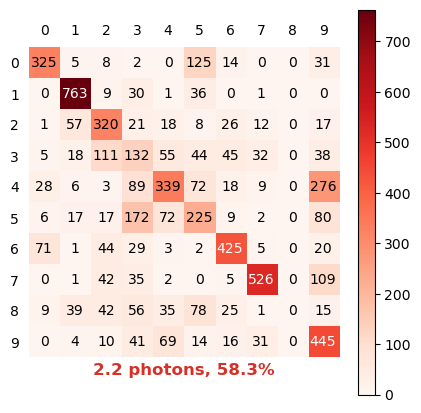

d_f = 9: 5.0 photons, 76.5%


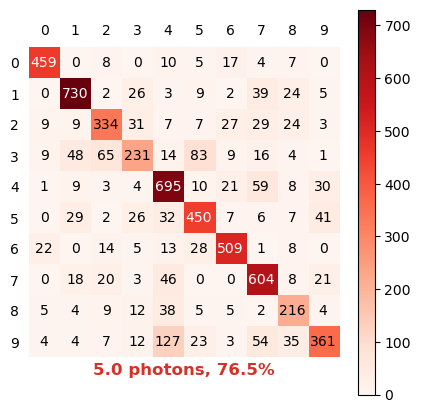

d_f = 16: 8.6 photons, 85.7%


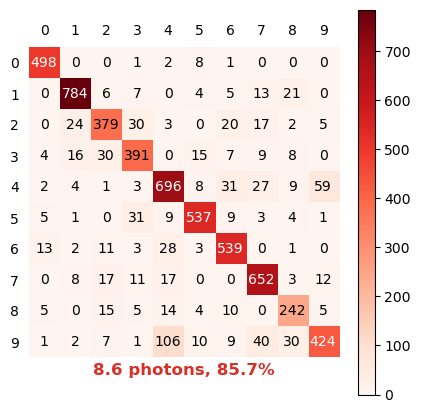

d_f = 25: 13.0 photons, 91.9%


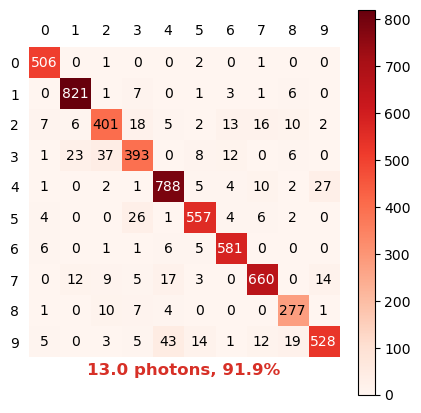

d_f = 36: 18.0 photons, 95.1%


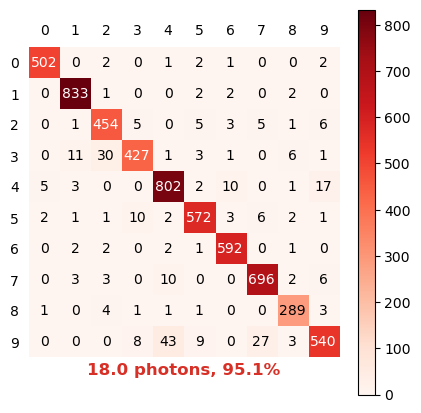

d_f = 64: 29.3 photons, 97.2%


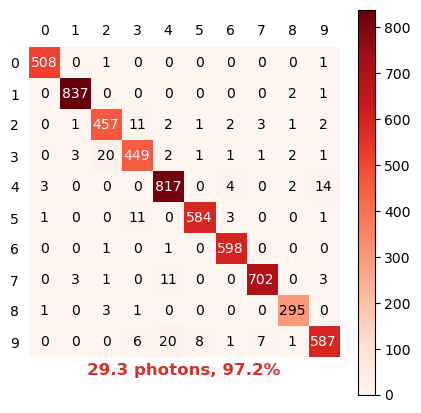

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

MNIST_LABELS = [str(i) for i in range(10)]

def evaluate_acts(acts, model, images, labels, device='cpu'):
    """Evaluate model on given activations (same pattern as test_MNIST_clean)."""
    model.to(device)
    model.eval()

    with torch.no_grad():
        images, labels = images.to(device), labels.to(device)
        acts_t = torch.as_tensor(acts, dtype=torch.float32, device=device)
        outputs = model.acts_out(acts_t)
        _, predicted = torch.max(outputs, dim=1)

        correct = (predicted == labels).sum().item()
        total = labels.size(0)

    accuracy = 100.0 * correct / total
    conf_mat = confusion_matrix(labels.cpu().numpy(), predicted.cpu().numpy())

    return accuracy, conf_mat

def plot_confusion_matrix(cm, labels, title, save_path=None):
    """Plot and optionally save confusion matrix."""
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Reds')
    ax.figure.colorbar(im, ax=ax, aspect=23)

    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_aspect('equal')
    ax.tick_params(top=False, bottom=False, left=False, right=False)
    ax.spines[:].set_visible(False)

    ax.xaxis.set_label_position('bottom')

    ax.set_xlabel(title, fontsize=12, fontweight='bold', color='#d73027ff')

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')

    if save_path:
        plt.savefig(save_path)
    plt.show()

    return fig

K = 1
conf_mats = {}
mean_acc = {}

for N in exp_Ns:
    model = exp_models[N]
    det_actv = torch.from_numpy(
        exp_actvs[N].reshape(K, -1, test_batch_size, N, order='F').mean(axis=0)
    ).type(torch.float32)
    n_T = det_actv.shape[0]
    acc, conf_mat = evaluate_acts(det_actv[0].numpy(), model, test_input_i, test_labels_i, device=device)
    for i in range(n_T - 1):
        aa, cc = evaluate_acts(det_actv[i + 1].numpy(), model, test_input_i, test_labels_i, device=device)
        acc += aa
        conf_mat += cc
    acc = acc / n_T

    conf_mats[N] = np.asarray(conf_mat, dtype=np.int64)
    mean_acc[N] = acc

    N_det = det_actv.mean().item() * N
    title = f'{N_det:.1f} photons, {acc:.1f}%'

    print(f'd_f = {N}: {title}')
    plot_confusion_matrix(conf_mat, MNIST_LABELS, title,
                          save_path=plotPath / f'MNIST_exp_conf_mat_df{N}_{acc:.2f}.png')

ordered_N = sorted(conf_mats.keys())
save_kw = {f'cm_{N}': conf_mats[N] for N in ordered_N}
save_kw['Ns'] = np.array(ordered_N, dtype=np.int64)
save_kw['K'] = np.array(K, dtype=np.int32)
save_kw['mean_acc_percent'] = np.array([mean_acc[N] for N in ordered_N], dtype=np.float64)
save_kw['labels'] = np.array(MNIST_LABELS)
np.savez_compressed(savePath / 'MNIST_exp_conf_mats.npz', **save_kw)

# Simulated results

In [9]:
import pandas as pd
import numpy as np
import torch

def renorm(data, min_val, max_val):
    return data*(max_val-min_val)+min_val

# create a DataFrame for the results
sim_results_df = pd.DataFrame(columns=['N', 'K', 'mean_accuracy', 'std_dev'])
torch.manual_seed(0)

nr = 100
Ks = np.r_[1,2,3,5]
acc_arr = np.zeros((len(Ks),nr))

temp_results = []

for N in exp_Ns:
    for Ki, K in enumerate(Ks):
        for j in range(nr):
            output = exp_models[N](test_input_i,n_rep=K)
            pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct = pred.eq(test_labels_i.data.view_as(pred)).cpu().sum()
            acc_arr[Ki,j] = correct / test_batch_size

        mean_acc = 100. * acc_arr[Ki].mean()
        std_dev = 100. * acc_arr[Ki].std()

        # append the results to your DataFrame
        temp_results.append({'N': int(N), 'K': int(K), 'mean_accuracy': mean_acc, 'std_dev': std_dev})

sim_results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)


# Pivot the DataFrame so that 'K' are columns and 'N' are rows with 'mean_accuracy' and 'std_dev' together in the same cell
sim_results_df['results'] = sim_results_df.apply(lambda row: \
                            f"{np.round(row['mean_accuracy'],2):.2f} ± {np.round(row['std_dev'],2):.2f}%", axis=1)
sim_results_df_print = format_pivot(sim_results_df.pivot(index='N', columns='K', values='results'))

sim_results_df_print

,K = 1,K = 2,K = 3,K = 5
N = 4,60.28 ± 2.08%,64.15 ± 1.92%,65.38 ± 1.49%,67.03 ± 1.60%
N = 9,81.23 ± 2.03%,85.59 ± 1.72%,86.93 ± 1.27%,88.49 ± 1.21%
N = 16,89.96 ± 1.42%,92.32 ± 1.37%,93.11 ± 1.11%,93.42 ± 0.89%
N = 25,94.39 ± 1.35%,96.35 ± 0.97%,96.88 ± 0.69%,97.20 ± 0.66%
N = 36,97.28 ± 0.98%,98.20 ± 0.77%,98.47 ± 0.68%,98.63 ± 0.56%
N = 64,98.46 ± 0.75%,99.20 ± 0.54%,99.40 ± 0.45%,99.52 ± 0.38%


In [10]:
sim_results_df.to_pickle(savePath / 'MNIST_active_sim.npy')

## Comparison plot

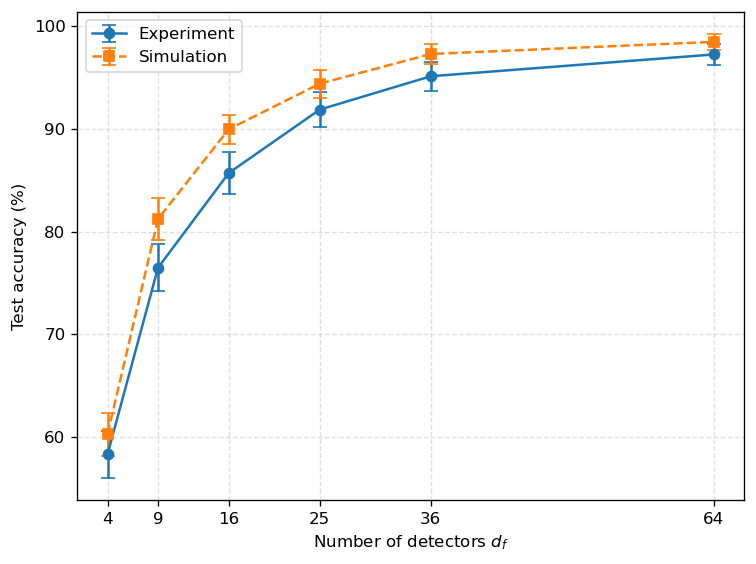

In [11]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

exp_sel = exp_results_df[exp_results_df['K'] == k_val].sort_values('N')
sim_sel = sim_results_df[sim_results_df['K'] == k_val].sort_values('N')

ax.errorbar(exp_sel['N'], exp_sel['mean_accuracy'], yerr=exp_sel['std_dev'],
            fmt='o-', label=f'Experiment', capsize=4)
ax.errorbar(sim_sel['N'], sim_sel['mean_accuracy'], yerr=sim_sel['std_dev'],
            fmt='s--', label=f'Simulation', capsize=4)

ax.set_xlabel(r'Number of detectors $d_f$')
ax.set_ylabel('Test accuracy (%)')
ax.set_xticks(sorted(exp_sel['N'].unique()))
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()